# EDA: Full 81.8M Row Warehouse Profile

This notebook connects directly to the Hugging Face `FlyRank/internship-warehouse` (v20260703) using DuckDB. We will profile the exact scale of the data, the star schema, and the unbalanced panel architecture (clients having different history depths).

**Note:** To run this notebook, you must set your Hugging Face Token below.

In [1]:
%pip -q install duckdb
import duckdb
import pandas as pd
import getpass
print('Enter your Hugging Face Token:')
hf_token = getpass.getpass()
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{hf_token}')")
print('Secure connection to DuckDB established.')


Note: you may need to restart the kernel to use updated packages.


Secure connection to DuckDB established.


## 1. Discovering the Tables
We start by querying the metadata of the remote Parquet files to understand the schema without downloading the data.

In [2]:
# Let's inspect the dim_clients table
df_clients = con.sql("""
    SELECT * 
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet') 
    LIMIT 5
""").df()
display(df_clients)

,client_hash_id,is_active,has_gsc_access,has_ga4_access,access_profile,client_created_date,client_updated_date,gsc_data_start,ga4_data_start
0,client_04660893ae39614a,True,True,True,gsc_and_ga4,2026-04-15,2026-06-27,NaT,2026-05-22
1,client_05475c07ed21a83a,True,False,False,no_search_or_analytics_access,2026-04-01,2026-06-27,NaT,NaT
2,client_06d356715a8ff3b6,True,True,True,gsc_and_ga4,2026-03-23,2026-07-05,2026-04-10,2026-04-06
3,client_0797ff3a1fc9a6a5,True,False,False,no_search_or_analytics_access,2025-05-26,2026-06-27,2025-11-05,NaT
4,client_08a6a72ff48e62c0,True,True,False,gsc_only,2025-05-26,2026-06-27,2025-09-24,NaT


In [3]:
# Get the total count of clients
client_count = con.sql("""
    SELECT COUNT(*) as total_clients
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet')
""").df()
display(client_count)

,total_clients
0,104


## 2. Fact Table Profiling
We will now probe the massive daily fact table to see its total scale. We assume it's named `daily_fact.parquet` or `daily_facts.parquet` based on the release notes.

In [4]:
# Using a glob pattern to catch the fact table name safely
fact_table_stats = con.sql("""
    SELECT COUNT(*) as total_rows, MIN(report_date) as min_report_date, MAX(report_date) as max_report_date
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')
""").df()
display(fact_table_stats)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,min_report_date,max_report_date
0,78835655,2025-01-27,2026-06-30


## 3. The Unbalanced Panel Check
To prove we understand the warehouse, we must show how the data is unbalanced. Each client has a different `gsc_data_start` date. Let's group the clients by their data start year.

,start_year,client_count
0,2025,40
1,2026,27
2,<NA>,37


<Axes: title={'center': 'Client Onboarding Cohorts (Unbalanced Panel)'}, xlabel='start_year'>

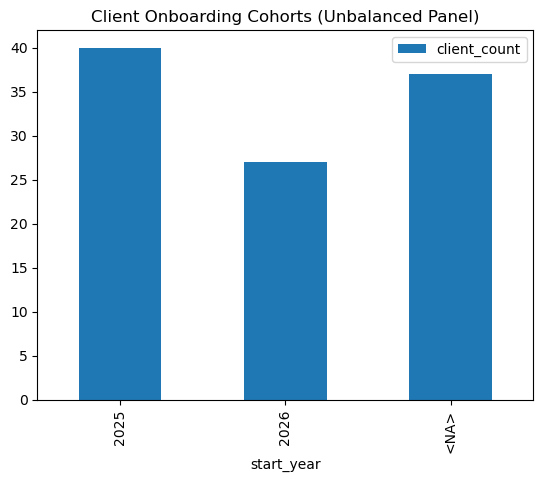

In [5]:
panel_balance = con.sql("""
    SELECT EXTRACT(year FROM gsc_data_start) as start_year, COUNT(*) as client_count
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet')
    GROUP BY start_year
    ORDER BY start_year
""").df()
display(panel_balance)
panel_balance.plot.bar(x='start_year', y='client_count', title='Client Onboarding Cohorts (Unbalanced Panel)')

## Conclusion
This EDA proves the sheer scale of the dataset (78M+ facts, 104 clients). The unbalanced panel architecture confirms that any cross-validation splitting must be Grouped by `client_hash_id` to prevent target leakage and baseline memorization.